In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../..')
from sn_clf.scripts.utils import plot_config

plot_config()

In [19]:
offsets = {
    '533202300011210':
    {
        'Epoch 1 (1st burst)':	[0.0, 0.0, 0.11, 0.11],
        'Epoch 2':	[-0.03,	0.24,	0.06,	0.08],
        'Epoch 3 (2nd burst)':	[0.0,	-0.09,	0.10,	0.09]
    },

    '580214400011443':
    {
        'Host center':	[0.0, 0.0,	0.07,	0.13],
        'Epoch 2 (1st burst)':	[-8.31,	10.36,	0.07,	0.13],
        'Epoch 3 (2nd burst)':	[-7.12,	11.47,	0.06,	0.11],
    },

    '680211300006932':
    {
        'Host center':	[0.0,	0.0,	0.05,	0.08],
        'Epoch 1 (1st burst)':	[0.97,	0.63,	0.05,	0.08],
        'Epoch 2 (2nd burst)':	[-0.38,	0.59,	0.12,	0.22]
    }
}

In [20]:
oids = list(offsets.keys())

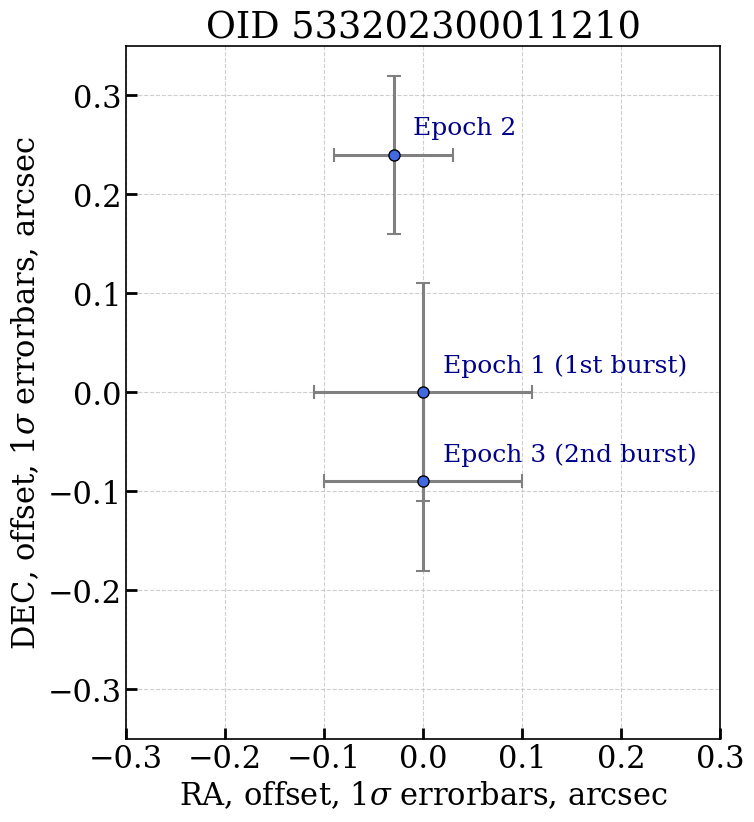

In [52]:
object_id = oids[0]
data = offsets[object_id]

# готовим данные для построения
labels = list(data.keys())
x = [data[label][0] for label in labels]
y = [data[label][1] for label in labels]
dx = [data[label][2] for label in labels]
dy = [data[label][3] for label in labels]

# создаём фигуру
plt.figure(figsize=(9, 9))

# рисуем точки с errorbar
plt.errorbar(x, y, xerr=dx, yerr=dy, fmt='o', capsize=5, capthick=1.5,
             ecolor='gray', markersize=8, markerfacecolor='royalblue', markeredgecolor='black', linestyle='None')

# подписываем точки
for i, label in enumerate(labels):
    plt.text(x[i] + 0.02, y[i] + 0.02, label, fontsize=18, color='darkblue')

# оформление
plt.title(f'OID {object_id}')
plt.xlabel(r'RA, offset, $1\sigma$ errorbars, arcsec')
plt.ylabel(r'DEC, offset, $1\sigma$ errorbars, arcsec')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.3, 0.3)
plt.ylim(-0.35, 0.35)

plt.gca().set_aspect('equal', adjustable='box')
#plt.savefig(f'../figures/{object_id}_offset.pdf', dpi=400, format='pdf', bbox_inches="tight")

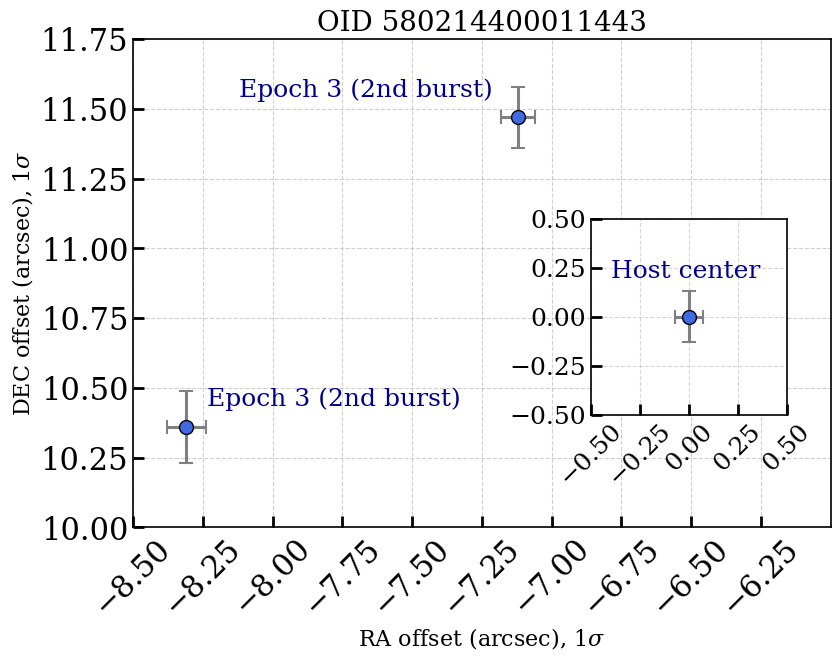

In [129]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

# данные
offsets = {
    '580214400011443': {
        'Host center': [0.0, 0.0, 0.07, 0.13],
        'Epoch 2 (1st burst)': [-8.31, 10.36, 0.07, 0.13],
        'Epoch 3 (2nd burst)': [-7.12, 11.47, 0.06, 0.11],
    }
}

object_id = '580214400011443'
data = offsets[object_id]

labels = list(data.keys())
x = np.array([data[label][0] for label in labels])
y = np.array([data[label][1] for label in labels])
dx = np.array([data[label][2] for label in labels])
dy = np.array([data[label][3] for label in labels])

# индексы
host_idx = labels.index('Host center')
other_idx = [i for i in range(len(labels)) if i != host_idx]

# данные для основного графика
x_main = x[other_idx]
y_main = y[other_idx]
dx_main = dx[other_idx]
dy_main = dy[other_idx]
labels_main = [labels[i] for i in other_idx]

# хост
x_host = x[host_idx]
y_host = y[host_idx]
dx_host = dx[host_idx]
dy_host = dy[host_idx]

# фигура
fig, ax = plt.subplots(figsize=(9, 9))

# основной график
ax.errorbar(x_main, y_main, xerr=dx_main, yerr=dy_main,
            fmt='o', capsize=5, capthick=1.5,
            ecolor='gray', markersize=10,
            markerfacecolor='royalblue', markeredgecolor='black',
            linestyle='None')


ax.text(x_main[0] + 0.075, y_main[0] + 0.075, lab, fontsize=18, color='darkblue')
ax.text(x_main[1] - 1, y_main[1] + 0.075, lab, fontsize=18, color='darkblue')

ax.set_title(f'OID {object_id}', fontsize=20)
ax.set_xlabel(r'RA offset (arcsec), $1\sigma$', fontsize=16)
ax.set_ylabel(r'DEC offset (arcsec), $1\sigma$', fontsize=16)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_aspect('equal', adjustable='box')

# лимиты по основным точкам
x_margin = (x_main.max() - x_main.min()) * 0.15
y_margin = (y_main.max() - y_main.min()) * 0.15


# --- чистый inset без выделений ---
axins = inset_axes(ax, width="40%", height="40%",
                   bbox_to_anchor=(0.575, 0.2, 1, 1),  # (x0, y0, width, height) в координатах Axes
                   bbox_transform=ax.transAxes,
                   loc='lower left',
                  )
axins.text(-0.4, 0.2, 'Host center', fontsize=18, color='darkblue')

# зум вокруг хоста
rx = 0.5
ry = 0.5
axins.set_xlim(x_host - rx, x_host + rx)
axins.set_ylim(y_host - ry, y_host + ry)

# рисуем хост в inset
axins.errorbar([x_host], [y_host], xerr=[dx_host], yerr=[dy_host],
               fmt='o', capsize=5, capthick=1.5,
               ecolor='gray', markersize=10,
               markerfacecolor='royalblue', markeredgecolor='black')

#axins.set_title("Host center", fontsize=12)
axins.grid(True, linestyle='--', alpha=0.5)
axins.set_aspect('equal', adjustable='box')
axins.set_xticks(np.arange(-0.5, 0.6, 0.25))
axins.set_yticks(np.arange(-0.5, 0.6, 0.25))
axins.tick_params(axis='x', rotation=45, labelsize=18)
axins.tick_params(axis='y', labelsize=18)



ax.set_xticks(np.arange(-8.5, -6, 0.25))
ax.set_yticks(np.arange(10, 11.8, 0.25))

ax.set_xlim(-8.5, -6)
ax.set_ylim(10, 11.75)
ax.tick_params(axis='x', rotation=45)

plt.savefig(f'../figures/{object_id}_offset.pdf', dpi=400, format='pdf', bbox_inches="tight")